## Clinical Testing & Sequencing Metrics: CoV Case Study

### Core Classification (The Confusion Matrix)
* **N:** the number of observations.
* **True Positive (TP):** Sequence is **CoV**; identified as **CoV**. Correct detection.
* **True Negative (TN):** Sequence is **NOT CoV**; identified as **NOT CoV**. Correct exclusion.
* **False Positive (FP):** **Type I Error** (rejecting a true null). Sequence is **NOT CoV**; identified as **CoV**.
    * *Cause:* Sequencing errors accidentally match a **CoV key**.
    * *Solution:* Improve **pore accuracy**, ignore low counts.
* **False Negative (FN):** **Type II Error** (failing to reject a false null). Sequence is **CoV**; identified as **NOT CoV**.
    * *Cause:* Sequence missed the pore or errors prevented a key match.
    * *Solution:* Increase observation time, use **PCR** amplification, or improve **pore accuracy**.

---

### Key Performance Metrics
* **Accuracy:** is $(TP + TN)/N$
* **Sensitivity (Recall / TPR):** $TP / (TP + FN)$. Ability to correctly identify those with the disease. Aim for the highest possible value.
* **Specificity:** $TN / (TN + FP)$. Ability to correctly identify those without the disease.
* **Precision (PV+ / PPV):** $TP / (TP + FP)$. Probability that a positive result is actually positive.
* **F-Measure (F1-Score):** $2 * (Recall * Precision) / (Recall + Precision)$. Harmonic mean of Precision and Recall.
* **FPR (False Positive Rate):** $1 - \text{Specificity}$ or $FP / (FP + TN)$.
* **PV- (Negative Predictive Value):** $TN / (TN + FN)$. Probability that a negative result is actually negative.
* **LR+ (Positive Likelihood Ratio):** $Sensitivity / (1 - Specificity)$.
* **LR- (Negative Likelihood Ratio):** $(1 - Sensitivity) / Specificity$.

---

### Evaluation Curves
* **ROC Curve:** A plot of **FPR** (X-axis) against **TPR** (Y-axis).
* **AUC (Area Under the Curve):** Measures **separability** (the model's ability to distinguish classes).
    * **1.0:** Perfect model.
    * **0.5:** Random guessing (worst case).
    * **< 0.5:** Reciprocating/inverted results.

In [31]:
# We have some student data about sex, age, and height.
data = """
Name,Sex,Age (years),Height (cm),Class
Olivia,Female,17.9,171.33,Senior
Joseph,Male,14.6,162.29,Freshman
Elijah,Male,15.2,170.89,Sophomore
Avery,Female,17.4,168.88,Senior
Evelyn,Female,14.2,154.88,Freshman
Ava,Female,15.9,152.53,Sophomore
Oliver,Male,14.5,168.39,Freshman
David,Male,14.8,164.23,Freshman
Lucas,Male,16.0,176.3,Junior
Hannah,Female,14.0,158.55,Freshman
Brooklyn,Female,17.1,164.91,Senior
Lily,Female,17.9,157.11,Senior
Sofia,Female,17.7,159.53,Senior
Oliver,Male,16.1,173.39,Junior
Daniel,Male,14.9,167.2,Freshman
Olivia,Female,14.8,160.98,Freshman
David,Male,16.0,172.6,Sophomore
Elijah,Male,16.8,175.87,Junior
Matthew,Male,17.8,166.27,Senior
Christopher,Male,17.4,169.14,Senior
James,Male,16.8,178.69,Junior
Elijah,Male,15.2,167.49,Sophomore
Ella,Female,15.1,159.27,Sophomore
Emily,Female,16.4,168.48,Junior
Elijah,Male,14.5,178.47,Freshman
Lucas,Male,17.6,173.61,Senior
Elizabeth,Female,17.9,156.99,Senior
Noah,Male,15.2,167.02,Sophomore
Noah,Male,17.2,177.3,Senior
William,Male,15.0,173.57,Sophomore
Victoria,Female,14.1,165.34,Freshman
Sebastian,Male,14.1,162.22,Freshman
Matthew,Male,16.1,181.99,Junior
Zoe,Female,14.5,157.97,Freshman
Emma,Female,14.5,157.45,Freshman
Ryan,Male,15.2,174.36,Sophomore
Amelia,Female,17.4,170.1,Senior
Sofia,Female,15.4,161.73,Sophomore
Isabella,Female,17.4,161.42,Senior
Samuel,Male,15.6,179.31,Sophomore
Emily,Female,15.9,160.24,Sophomore
Daniel,Male,17.8,172.19,Senior
Benjamin,Male,16.3,180.44,Junior
Grace,Female,15.1,165.07,Sophomore
Elizabeth,Female,14.1,166.86,Freshman
Evelyn,Female,16.9,163.51,Junior
Elizabeth,Female,17.1,164.09,Senior
Alexander,Male,15.4,171.61,Sophomore
Evelyn,Female,15.4,164.28,Sophomore
Evelyn,Female,15.1,161.13,Sophomore
"""

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [33]:
# We can read in the string of data into a data frame (df), and show it.
df = pd.read_csv(StringIO(data))
df.head() # Shows the first 5 rows.


,Name,Sex,Age (years),Height (cm),Class
0,Olivia,Female,17.9,171.33,Senior
1,Joseph,Male,14.6,162.29,Freshman
2,Elijah,Male,15.2,170.89,Sophomore
3,Avery,Female,17.4,168.88,Senior
4,Evelyn,Female,14.2,154.88,Freshman


In [34]:
# Quick split out of sex by age and height.
df.groupby('Sex').describe()

# We call 25% the first quartile or Q1, and 50% the second quartile or Q2, and 75% the third quartile or Q3.
# "min" is the minimum value. It's the same as 0% (or Q0), which mean 0% of the observations are less than that value.
# "max" is the maximum value. It's the same as 100% (or Q4), which mean 100% of the observations are less than or equal to that value.


Age (years)                                                  \
             count    mean       std   min   25%   50%   75%   max   
Sex                                                                  
Female        25.0  15.968  1.392456  14.0  14.8  15.9  17.4  17.9   
Male          25.0  15.844  1.118436  14.1  15.0  15.6  16.8  17.8   

       Height (cm)                                                              
             count      mean       std     min     25%     50%     75%     max  
Sex                                                                             
Female        25.0  162.1052  4.844727  152.53  158.55  161.42  165.07  171.33  
Male          25.0  172.1936  5.622041  162.22  167.49  172.60  176.30  181.99

# Box Plot
Sometimes called whisker plot, or candles.

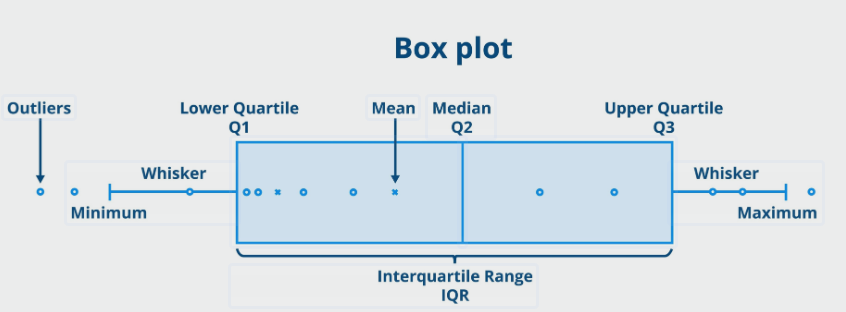

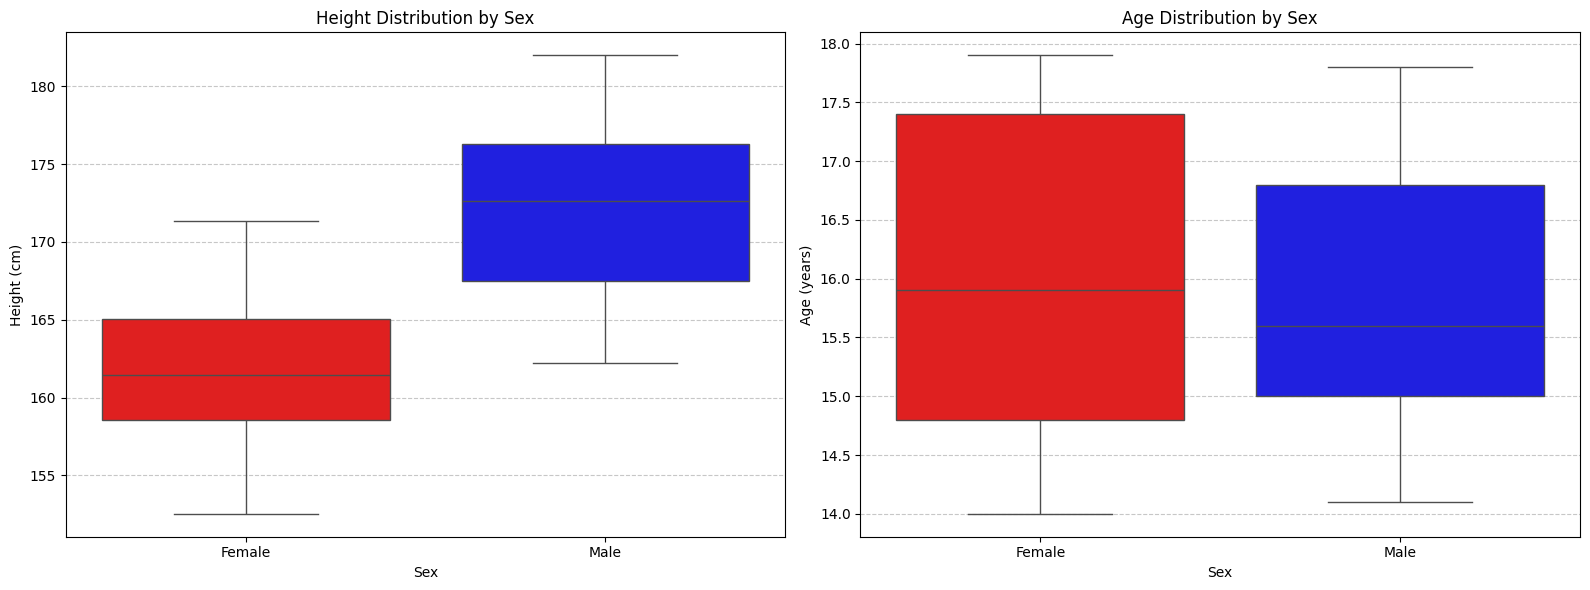

In [35]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot for Height (cm) by Sex
sns.boxplot(x='Sex', y='Height (cm)', data=df, palette={'Male': 'blue', 'Female': 'red'}, ax=axes[0])
axes[0].set_title('Height Distribution by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Height (cm)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Box plot for Age (years) by Sex
sns.boxplot(x='Sex', y='Age (years)', data=df, palette={'Male': 'blue', 'Female': 'red'}, ax=axes[1])
axes[1].set_title('Age Distribution by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Age (years)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

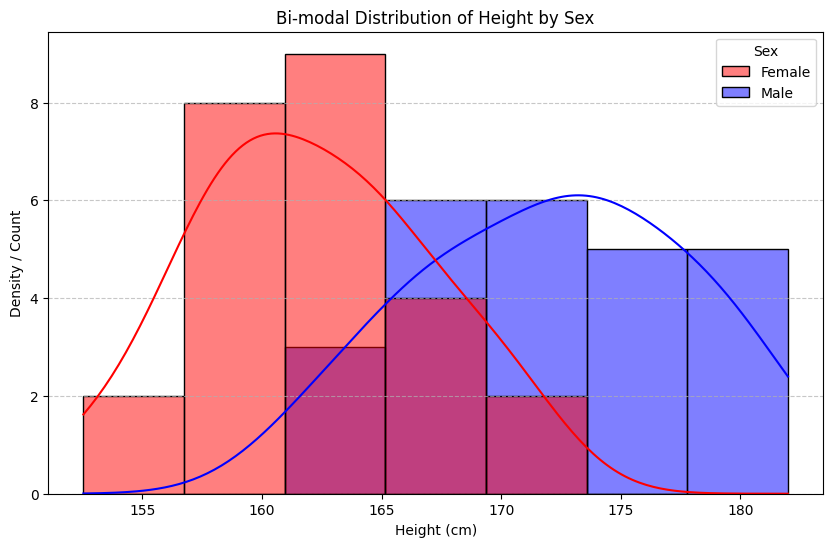

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Modal means something like hill. Bi modal means two of them. Multi-model, you get it.
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Height (cm)', hue='Sex', kde=True, palette={'Male': 'blue', 'Female': 'red'})
plt.title('Bi-modal Distribution of Height by Sex')
plt.xlabel('Height (cm)')
plt.ylabel('Density / Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

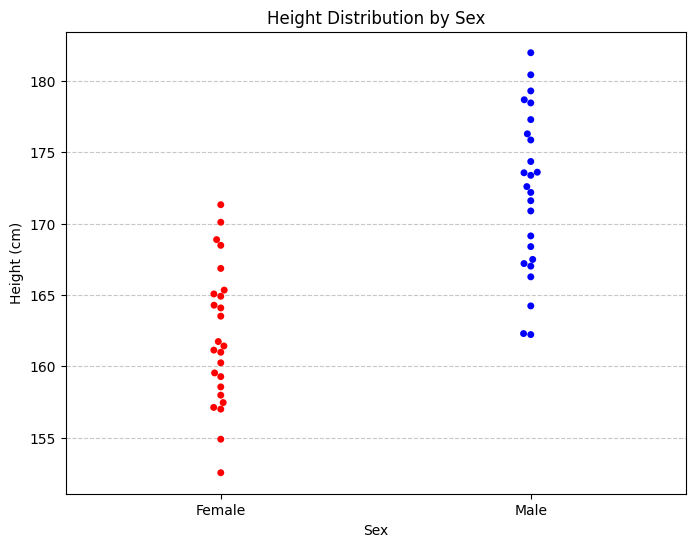

In [37]:
# Scatter plot these so you can see the density of the average.
plt.figure(figsize=(8, 6))
sns.swarmplot(x='Sex', y='Height (cm)', data=df, hue='Sex', palette={'Male': 'blue', 'Female': 'red'})

plt.title('Height Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Height (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Model
Let's create a model, which is function that takes an input (the height) to predict an output (the sex). So if you give me a height, like 170 cm, I say "Male". Obviously there will be some errors since all models have errors.

The simplest model is a horizontal line that cuts the height data. If you are above the line, we will say "Male", and if you are below the line we will say "Female".

In [38]:
def is_male(height, threshold):
    return height >= threshold

In [39]:
import pandas as pd

class ConfusionMatrix:
    def __init__(self):
        self.N = 0   # Total observations
        self.TP = 0  # True Positive
        self.TN = 0  # True Negative
        self.FP = 0  # False Positive
        self.FN = 0  # False Negative

    def add(self, predicted: bool, actual: bool):
        self.N += 1
        if predicted and actual:
            self.TP += 1
        elif not predicted and not actual:
            self.TN += 1
        elif predicted and not actual:
            self.FP += 1
        else: # not predicted and actual
            self.FN += 1

    def sensitivity(self):
        return self.TP / (self.TP + self.FN) if (self.TP + self.FN) > 0 else 0

    def specificity(self):
        return self.TN / (self.TN + self.FP) if (self.TN + self.FP) > 0 else 0

    def accuracy(self):
        return (self.TP + self.TN) / self.N if self.N > 0 else 0

    def precision(self):
        return self.TP / (self.TP + self.FP) if (self.TP + self.FP) > 0 else 0

    def F1_score(self):
        """
        Measures a model's 'balance' between Precision and Recall.
          1.0: Perfect Precision and Perfect Recall.
          0.5: A mediocre balance.
          0.0: The model failed completely in at least one category.
        Example: You make a model called has_disease() that always returns false.
        So this is useless, but you are testing for a disease that only 1 in
        1000 people have, so your model is 99.9% accurate. Still useless.
        """
        prec = self.precision()
        rec = self.sensitivity()
        return 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    def FPR(self):
        "False Positive Rate"
        return 1 - self.specificity()

    def TPR(self):
        "True Positive Rate"
        return self.sensitivity()

    def get_confusion_matrix(self):
        # 1. Create the small 2x2 data dictionary
        data = {
            'Predicted Male': [self.TP, self.FP],
            'Predicted Female': [self.FN, self.TN]
        }

        # 2. Create the 2x2 DataFrame specifically for the matrix
        matrix_df = pd.DataFrame(data, index=['Actual Male', 'Actual Female'])

        # 3. Apply the styles to THIS small matrix_df
        return matrix_df.style.set_properties(**{
            'border': '1.5px solid black',
            'text-align': 'center'
        }).set_table_styles([{
            'selector': 'th',
            'props': [('border', '1.5px solid black'), ('background-color', '#f2f2f2')]
        }])

    def get_heatmap_matrix(self):
        data = {
            'Predicted Male': [self.TP, self.FP],
            'Predicted Female': [self.FN, self.TN]
        }
        df = pd.DataFrame(data, index=['Actual Male', 'Actual Female'])

        # Colors the background (higher numbers = darker blue)
        return df.style.background_gradient(cmap='Blues').set_properties(**{'border': '1px solid gray'})


    def __repr__(self):
        return f"Acc: {self.accuracy():.2f} | Sens: {self.sensitivity():.2f} | Spec: {self.specificity():.2f}"

In [40]:
# We guess at the threshold as a single example of a model.
threshold = 170
cm = ConfusionMatrix()

# For each row (or observation) in data...
for index, row in df.iterrows():
    # See if it is a male or not.
    actual = (row['Sex'] == 'Male')

    # Run the height through the model to see what it guesses.
    predicted = is_male(row['Height (cm)'], threshold)

    # Add the predicted and actual to the confusion matrix.
    cm.add(predicted, actual)

# And finally print it out.
print("Confusion Matrix for Threshold =", threshold, "cm:")
cm.get_confusion_matrix()

Confusion Matrix for Threshold = 170 cm:


,Predicted Male,Predicted Female
Actual Male,16,9
Actual Female,2,23


In [41]:
# A heat map is a confusion matrix where you make bigger numbers more red (hotter) and smaller numbers more blue (colder).
# In this case, the colors should be reversed since errors are more likely to be red conventionally.
cm.get_heatmap_matrix()

,Predicted Male,Predicted Female
Actual Male,16,9
Actual Female,2,23


In [42]:
print(f"\nAccuracy: {cm.accuracy():.2f}")
print(f"Sensitivity (Recall): {cm.sensitivity():.2f}")
print(f"Specificity: {cm.specificity():.2f}")
print(f"Precision: {cm.precision():.2f}")
print(f"F1-Score: {cm.F1_score():.2f}")


Accuracy: 0.78
Sensitivity (Recall): 0.64
Specificity: 0.92
Precision: 0.89
F1-Score: 0.74


# Analysis
Here's what these numbers mean:

* True Positives (TP): 16 students were actually male and were correctly predicted as male.
* False Positives (FP): 2 students were actually female but were incorrectly predicted as male (Type I error).
* False Negatives (FN): 9 students were actually male but were incorrectly predicted as female (Type II error).
* True Negatives (TN): 23 students were actually female and were correctly predicted as female.

From these values, the following performance metrics were calculated:

* Accuracy (0.78): The model correctly classified 78% of the students overall.
* Sensitivity (Recall) (0.64): The model correctly identified 64% of all actual males.
* Specificity (0.92): The model correctly identified 92% of all actual females.
* Precision (0.89): When the model predicted a student was male, it was correct 89% of the time. So how often is it right?
* F1 Score (0.74): The model has a good balance between Precision and Recall. On a scale of 0 to 1, where 1 is a perfect model and 0 is a total failure, 0.74 suggests the model is performing well but still has room for improvement—likely through reducing either false positives or false negatives.

This shows that while the model has good overall accuracy and is quite good at identifying females and at being correct when it predicts males, it struggles a bit more with correctly identifying all actual males (higher False Negatives).

# Can we improve the model?

Let's make different thresholds for the model (called scenarios) and test each one to see which is the best model. We will use a parameter sweep.

In [43]:
# Create a new function that takes and entire data set (df) and a threshold (to create a new model)
# runs all the data through that specific model (defined by the threshold variable),
# and returns a confusion matrix.
# This allows us to run many different models so we can pick the best one - sometimes
# called "tuning" the model.
def test_threshold(df, threshold):
    cm = ConfusionMatrix()
    for _, row in df.iterrows():
        actual_is_male = (row['Sex'] == 'Male')
        predicted_is_male = is_male(row['Height (cm)'], threshold)
        cm.add(predicted_is_male, actual_is_male)
    return cm

In [44]:
# Define a new dataset for each scenario run.
# A scenario is a different model that runs all the data to get a confusion matrix.
results = []

# Create a bunch of scenarios - each with a different threshold by
# looping from min to max (150 to 181) creating a specific model for that threshold.
for t in range(150, 181):
    cm = test_threshold(df, t)

    # Add the results of this new model to the results.
    results.append({
        'Threshold': t,
        'Accuracy': cm.accuracy(),
        'Sensitivity': cm.sensitivity(),
        'Specificity': cm.specificity()
    })

# Convert to a DataFrame to find the winner
results_df = pd.DataFrame(results)
results_df

,Threshold,Accuracy,Sensitivity,Specificity
0,150,0.50,1.00,0.00
1,151,0.50,1.00,0.00
2,152,0.50,1.00,0.00
3,153,0.52,1.00,0.04
4,154,0.52,1.00,0.04
5,155,0.54,1.00,0.08
6,156,0.54,1.00,0.08
7,157,0.56,1.00,0.12
8,158,0.62,1.00,0.24
9,159,0.64,1.00,0.28


In [45]:
# Sort by Accuracy (highest first). You can see that 166 is the best model for integer height
# but only if we use "accuracy" as the measure. The thresholds that maximize the
# sensitivity and specificity are slightly different, so you need to know what you are
# trying to improve. We picked "accuracy" for our example.
best_scenarios = results_df.sort_values(by='Accuracy', ascending=False)
display(best_scenarios.head(5))

,Threshold,Accuracy,Sensitivity,Specificity
16,166,0.84,0.88,0.80
17,167,0.84,0.84,0.84
15,165,0.80,0.88,0.72
19,169,0.80,0.68,0.92
12,162,0.78,1.00,0.56


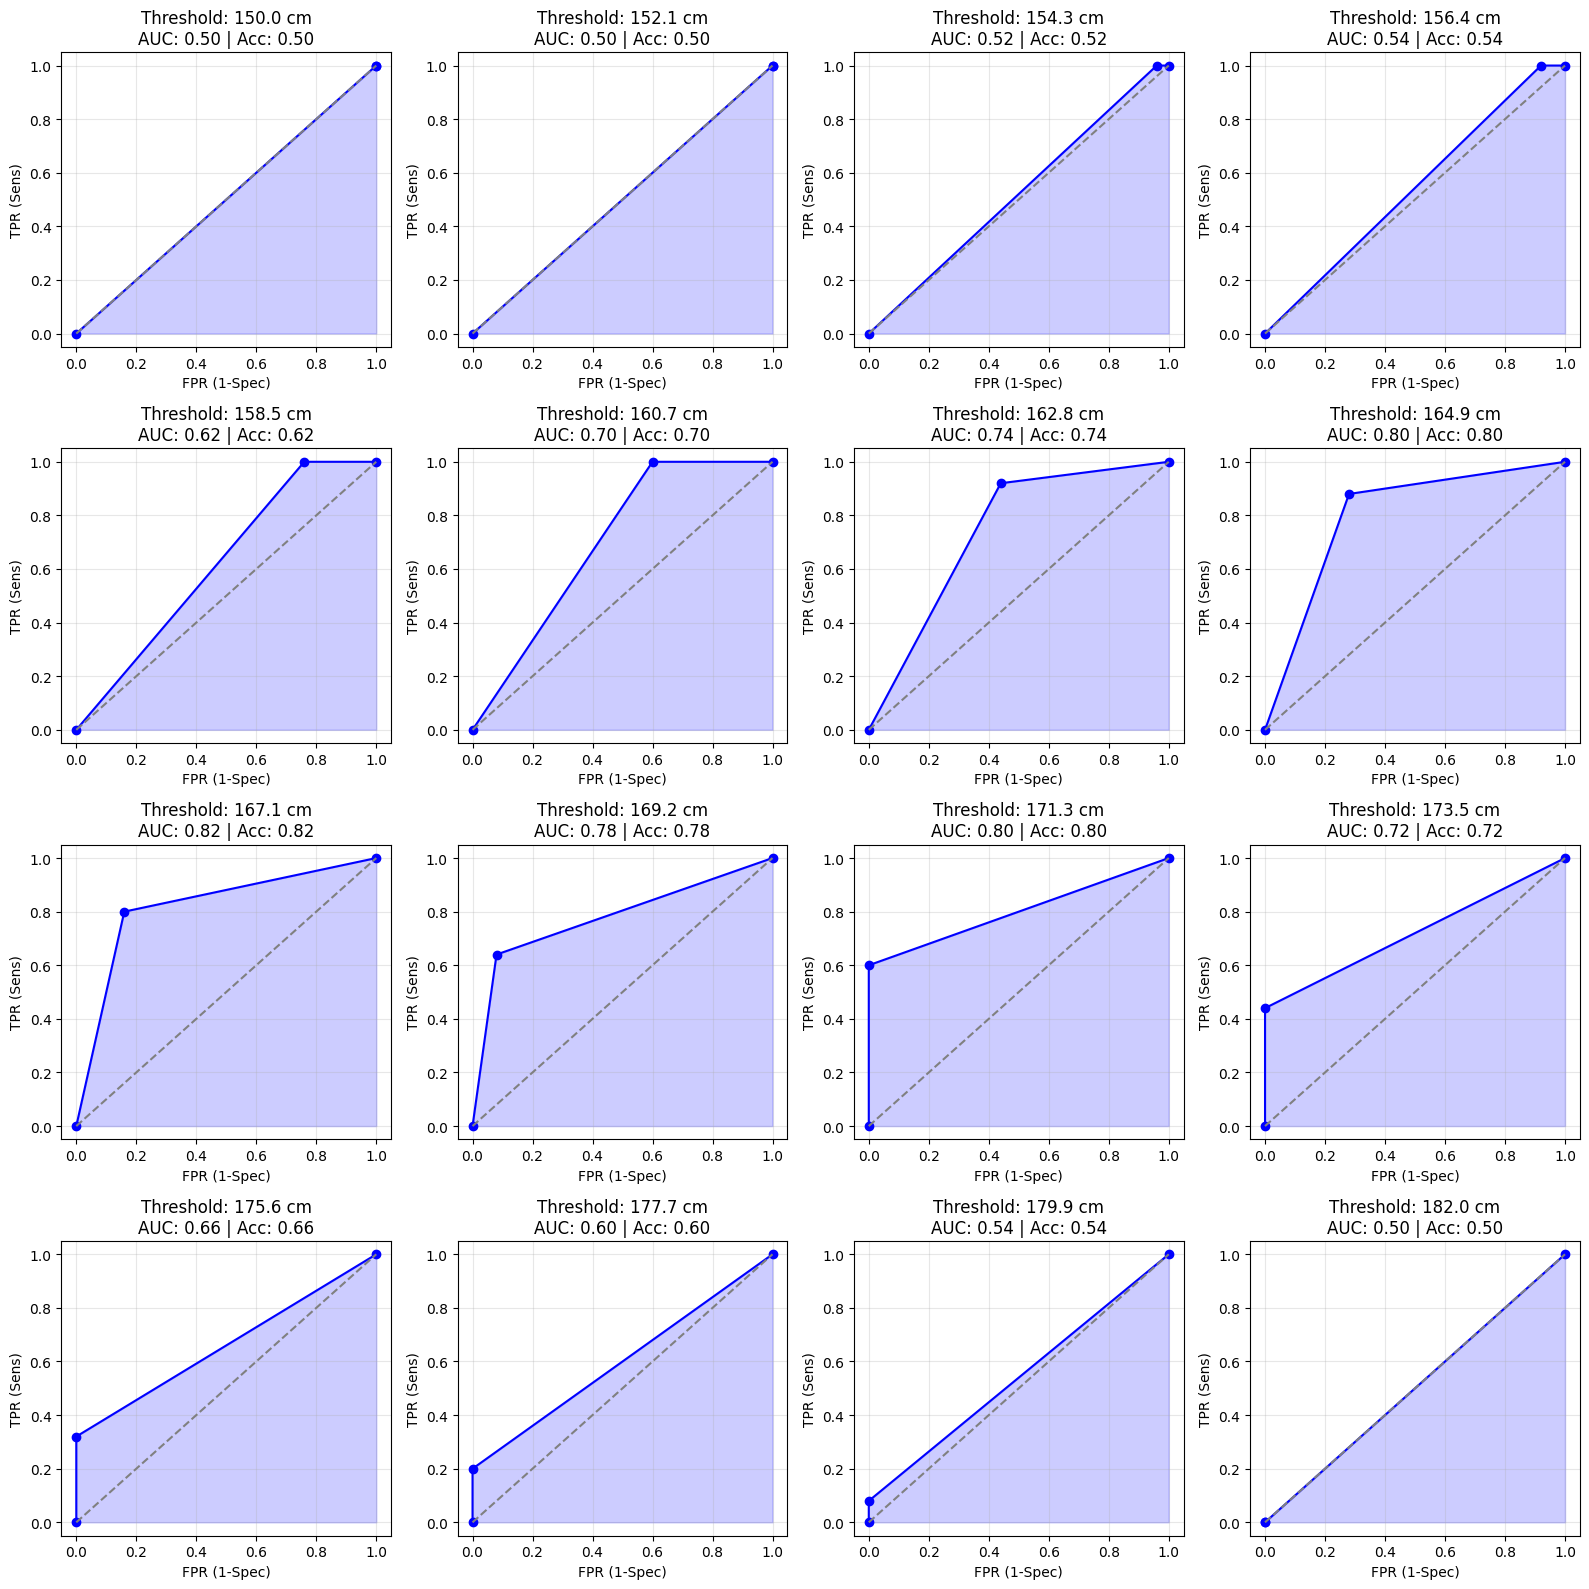

In [30]:
# Let's create 16 models using the "parameter sweep" method above.

# Divide the line from 150 to 182 (min and max) into 16 equal values
# so we can plot a 4 x 4 set of graphs.
# In the example paper here: https://www.sciopen.com/local/article_pdf/10.32604/cmc.2025.063961.pdf
# they create one chart with multiple AUC-ROC curves overlayed on the one chart,
# But we're going to split them out.

thresholds = np.linspace(150, 182, 16)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, t in enumerate(thresholds):
    cm = ConfusionMatrix()
    for _, row in df.iterrows():
        actual_is_male = (row['Sex'] == 'Male')
        predicted_is_male = is_male(row['Height (cm)'], t)
        cm.add(predicted_is_male, actual_is_male)

    # Calculate points for the ROC curve of this specific binary classifier
    # An ROC curve for a single threshold is (0,0) -> (FPR, TPR) -> (1,1)
    tpr = cm.sensitivity()
    fpr = 1 - cm.specificity()

    # AUC for this triangle is 0.5 * (1 + TPR - FPR)
    auc = 0.5 * (1 + tpr - fpr)

    ax = axes[i]
    ax.plot([0, fpr, 1], [0, tpr, 1], marker='o', color='blue', label=f'Threshold ROC')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    ax.fill_between([0, fpr, 1], [0, tpr, 1], alpha=0.2, color='blue')

    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.set_title(f"Threshold: {t:.1f} cm\nAUC: {auc:.2f} | Acc: {cm.accuracy():.2f}")
    ax.set_xlabel("FPR (1-Spec)")
    ax.set_ylabel("TPR (Sens)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parameter_sweep_roc.png')

# Also generate a table of results for the user
results = []
for t in np.linspace(150, 175, 30): # More granular for the table
    cm = ConfusionMatrix()
    for _, row in df.iterrows():
        cm.add(is_male(row['Height (cm)'], t), row['Sex'] == 'Male')
    results.append({'Threshold': round(t, 2), 'Accuracy': cm.accuracy(), 'Sens': cm.sensitivity(), 'Spec': cm.specificity()})

results_df = pd.DataFrame(results)
results_df.to_csv('threshold_sweep_results.csv', index=False)

An **AUC-ROC curve** (Area Under the Receiver Operating Characteristic curve) is a visualization of how well your classification model distinguishes between two groups—in your case, **Male** vs. **Female**.

Think of it as a "balancing act" between your model's ability to catch the target (Sensitivity) and its tendency to raise false alarms (1-Specificity).

### 1. The Anatomy of the Curve
The plot has two main axes:
* **Y-Axis: True Positive Rate (Sensitivity / Recall):** This is the percentage of actual Males that your model correctly identified. Higher is better.
* **X-Axis: False Positive Rate (1 - Specificity):** This is the percentage of actual Females that your model "missed" and incorrectly labeled as Male. Lower is better.



### 2. How to Read the Line
* **The Diagonal Line (The "Random" Line):** The dashed line from $(0,0)$ to $(1,1)$ represents a model that just guesses randomly (like flipping a coin). It has an AUC of **0.5**.
* **The "Perfect" Point:** The top-left corner $(0,1)$ is the goal. At this point, your model has 100% Sensitivity (finds all males) and 0% False Positives (misidentifies zero females).
* **The Curve:** As you change your height threshold, your model moves along a path. If your curve "bows" toward that top-left corner, your model is performing well.

### 3. What is the AUC?
The **AUC (Area Under the Curve)** is a single number that summarizes the entire plot:
* **AUC = 1.0:** A perfect model. It separates the two groups with zero overlap.
* **AUC = 0.8 to 0.9:** An excellent model.
* **AUC = 0.5:** No better than a coin flip.
* **AUC < 0.5:** Something is wrong—your model is actually predicting the *opposite* of the truth.



### 4. How to identify a "Better" Model?
When comparing two models (or two different thresholds), the "better" one is generally:
1.  **The one with the higher AUC:** It has a better overall ability to separate the classes across all possible settings.
2.  **The one "closest" to the top-left:** If you have a specific business goal (like "I must never misidentify a female"), you look for the point on the curve that minimizes the X-axis while keeping the Y-axis as high as possible.

### In your Height Study:
If you look at your 4x4 matrix, the "better" models are the ones where the blue triangle occupies the most space. You'll notice that as the threshold moves to the extreme (150cm or 175cm), the AUC drops because the model becomes too biased toward one sex, making the "triangle" very thin.

**Would you like me to show you how to calculate the exact AUC value for your best-performing threshold?**

# Summary

* Simple data can have all sorts of ways to look at it.
* The threshold model we made is just a simplification. There are other models more complicated but much better, like neural networks, that will likely be more accurate.
* We can run parameter sweeps to tune a model for the best, most accurate parameters.

# Lessons Learned

* *All models are wrong, but some are useful* - [George Box](https://en.wikipedia.org/wiki/All_models_are_wrong)
* A model simplifies an understanding of the world at the expense of accuracy. The model we discovered is "If you are at least 166 cm then we guess you are a male." This model can make mistakes called TYPE I and TYPE II mistakes.
The confusion matrix shows us the errors.
* Wants and demands are the world of children, but tradeoffs are the world of adults.
* A data scientist is not supposed to care about the outcomes so they often talk in conditionals and tradeoffs rather than declaratives. IF you NEVER want to put an innocent person in jail, THEN you must let all guity people go free. That is the extreme tradeoff. But we don't do that, so we have a tradeoff. Our constitution tends to substitute TYPE I errors for TYPE II. We are more likely to let a guity person go free than put an innocent person in jail. So we say you are innocent until proven guilty and we make it very difficult to prove you are guilty if you are indeed innocent.

# More from AI
### 1. The "Metric Trap" (Accuracy vs. The Truth)
You’ll notice in your sweep that **Accuracy** can sometimes be a liar. If you had a dataset of 100 people where 99 were Female and only 1 was Male, a model that simply guesses "Female" every time would be **99% accurate**, but it would be **0% sensitive** (it failed to find the 1 male).
* **The Lesson:** Never trust a single number. You must look at the balance between Sensitivity, Specificity, and Precision to see the "character" of your model.


### 2. Features Have "Ceilings"
Your model is based entirely on **Height**. No matter how many "scenarios" you run or how much you sweep the threshold, you will eventually hit a wall where the model cannot get any better because the data itself overlaps.
* **The Lesson:** To break through a performance ceiling, you don't need a better threshold; you need a better **feature**. (In your data, maybe adding "Weight" or "Hair Length" would separate the groups better than Height alone).

### 3. The "Cost" of Being Wrong is Asymmetric
In your code, every error is treated as `+1`. But in the real world, errors have different costs.
* **The Lesson:** In a CoV (Covid) case study, a **False Negative** (telling a sick person they are healthy) is much more "expensive" than a **False Positive** (telling a healthy person to stay home for a few days). A data scientist must weight the confusion matrix based on the "cost of the mistake."

### 4. Overfitting the "Now"
By running a parameter sweep on these specific 50 students, you might find a "perfect" threshold (like 163.3 cm) that works for *this* class. But if you take that model to a different school, it might fail miserably.
* **The Lesson:** A model that is too perfectly tuned to one dataset is "overfit." True "intelligence" in a model is its ability to **generalize** to data it has never seen before.

### 5. Precision-Recall Trade-off
You can't have your cake and eat it too. As you increase the threshold to be more **Precise** (so when you say "Male," you are almost always right), your **Recall** (finding all the males) will almost certainly go down.
* **The Lesson:** Engineering a model is not about finding "perfection"; it is about choosing a **compromise** that fits your specific goal.
